# 🦷 Dental Health Risk: ML for Oral Health Policy

**Author:** Dean Wang | Lead Data & AI Engineer

**Government:** Dept of Health, AIHW, Child Dental Benefits Schedule, state dental services

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2000, 12)


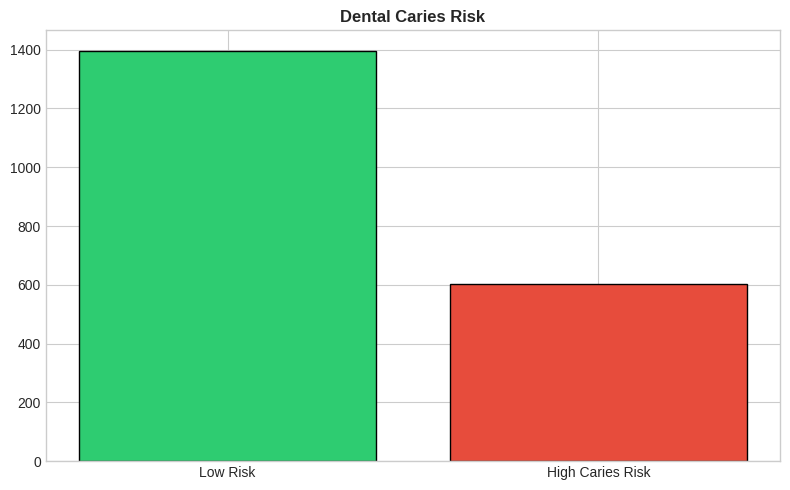

AU: Tooth decay is the most common chronic disease. 90% of adults have experienced caries.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2000,n_features=11,n_informative=8,n_classes=2,weights=[0.7,0.3],random_state=117)
names=['sugar_intake','brushing_frequency','last_checkup_months','fluoride_exposure','age','seifa_index','smoking_status','dry_mouth_indicator','diet_quality','dental_visit_barriers','prior_caries_count']
df=pd.DataFrame(X_arr,columns=names);df['high_caries_risk']=y;tc='high_caries_risk'
print(f"Generated: {df.shape}");labels=['Low Risk','High Caries Risk'];colors=['#2ecc71','#e74c3c']
fig,ax=plt.subplots(figsize=(8,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(2),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(2));ax.set_xticklabels(labels)
ax.set_title('Dental Caries Risk',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: Tooth decay is the most common chronic disease. 90% of adults have experienced caries.")

LogReg: Acc=0.9120 F1=0.8455 AUC=0.9445
RF: Acc=0.9280 F1=0.8724 AUC=0.9646
XGB: Acc=0.9365 F1=0.8923 AUC=0.9675
LGBM: Acc=0.9365 F1=0.8913 AUC=0.9680
Best: LGBM


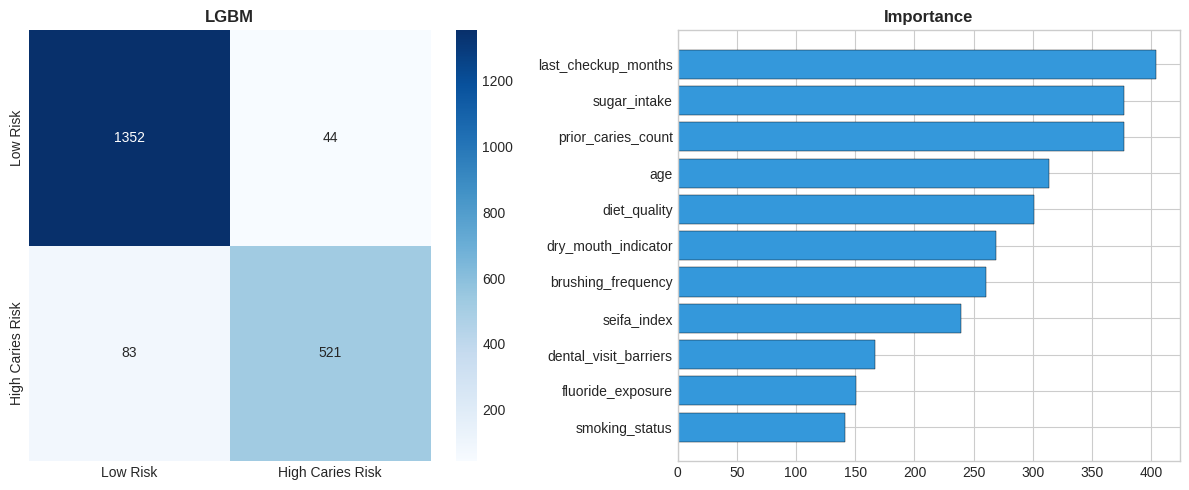

                  precision    recall  f1-score   support

        Low Risk       0.94      0.97      0.96      1396
High Caries Risk       0.92      0.86      0.89       604

        accuracy                           0.94      2000
       macro avg       0.93      0.92      0.92      2000
    weighted avg       0.94      0.94      0.94      2000

DEPLOYMENT: LGBM AUC=0.9680 | Dental records -> targeted CDBS prevention programs


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fu=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp));fu.append(roc_auc_score(y2[vi],yb))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f}")
best=max(results,key=lambda k:results[k]['auc']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold')
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['auc']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#3498db',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=labels))
br=results[best];print(f"DEPLOYMENT: {best} AUC={br['auc']:.4f} | Dental records -> targeted CDBS prevention programs")